Imports

In [86]:
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

Create Filtered CSV For EDA

In [87]:
# Notebook-friendly paths (no __file__ in Jupyter)
ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
TWEETS_PATH = DATA_DIR / 'tweets.txt'
EMOJI_PATH = DATA_DIR / 'emoji.txt'
OUT_CSV = DATA_DIR / 'filtered_tweets.csv'

# Remove all mentions
MENTION_RE = re.compile(r'@\w+')
URL_RE = re.compile(r'https?://\S+|www\.\S+', re.I)
# Remove leading "rt :" retweet prefix
RT_PREFIX_RE = re.compile(r'^\s*rt\s*:\s*', re.I)
SPACE_RE = re.compile(r'\s+')


def clean_tweet(text: str) -> str:
    text = URL_RE.sub('', text)
    text = MENTION_RE.sub('', text)
    text = SPACE_RE.sub(' ', text).strip()
    text = RT_PREFIX_RE.sub('', text)
    return text.strip()


def word_metrics(text: str) -> tuple[int, float]:
    """Whitespace token count and mean token length (chars)."""
    words = text.split()
    n = len(words)
    if not n:
        return 0, 0.0
    return n, sum(len(w) for w in words) / n


rows = []
with open(TWEETS_PATH, encoding='utf-8', errors='replace') as tf, open(
    EMOJI_PATH, encoding='utf-8', errors='replace'
) as ef:
    for line_no, (tweet_line, emoji_line) in enumerate(zip(tf, ef), start=1):
        raw = tweet_line.rstrip('\n\r')
        emoji_label = emoji_line.strip()
        mention_count = raw.count('@')
        is_retweet = raw.lstrip().lower().startswith('rt @')
        tweet_body = clean_tweet(raw)
        char_count = len(tweet_body)
        has_question_mark = '?' in tweet_body
        has_exclamation_mark = '!' in tweet_body
        has_hash = '#' in tweet_body
        capital_letter_count = sum(1 for c in tweet_body if c.isupper())
        word_count, avg_word_length = word_metrics(tweet_body)
        rows.append(
            {
                'LINE_NUM': line_no,
                'TWEET': tweet_body,
                'EMOJI': emoji_label,
                'CHAR_COUNT': char_count,
                'WORD_COUNT': word_count,
                'AVG_WORD_LENGTH': avg_word_length,
                'CAPITAL_LETTER_COUNT': capital_letter_count,
                'MENTION_COUNT': mention_count,
                'HAS_QUESTION_MARK': has_question_mark,
                'HAS_EXCLAMATION_MARK': has_exclamation_mark,
                'HAS_HASH': has_hash,
                'IS_RETWEET': is_retweet,
            }
        )

df = pd.DataFrame(rows)

# Remove dupe tweets
df = df[df['TWEET'].duplicated(keep=False)]
df.to_csv(OUT_CSV, index=False)

print(f'Wrote {len(df)} rows to {OUT_CSV}')

Wrote 100103 rows to c:\Users\avina\Emojithon\data\filtered_tweets.csv


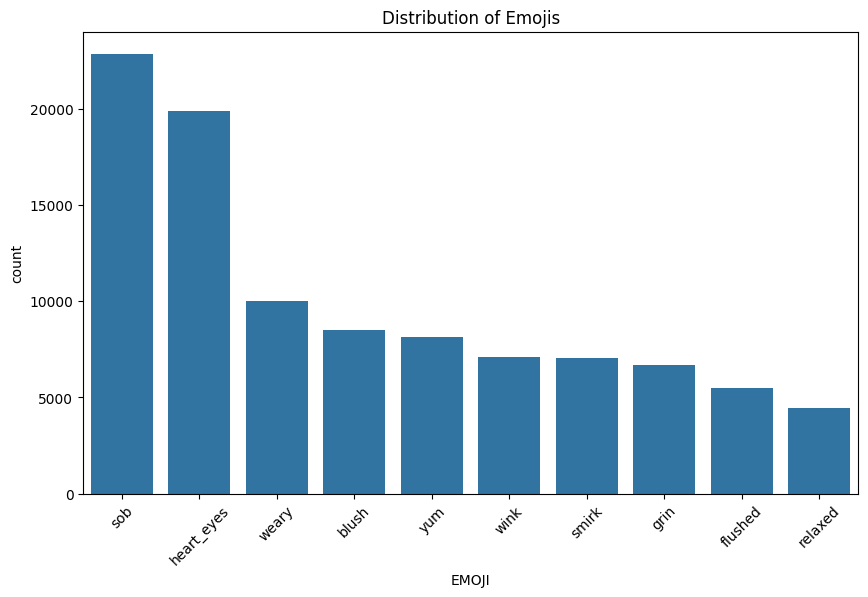

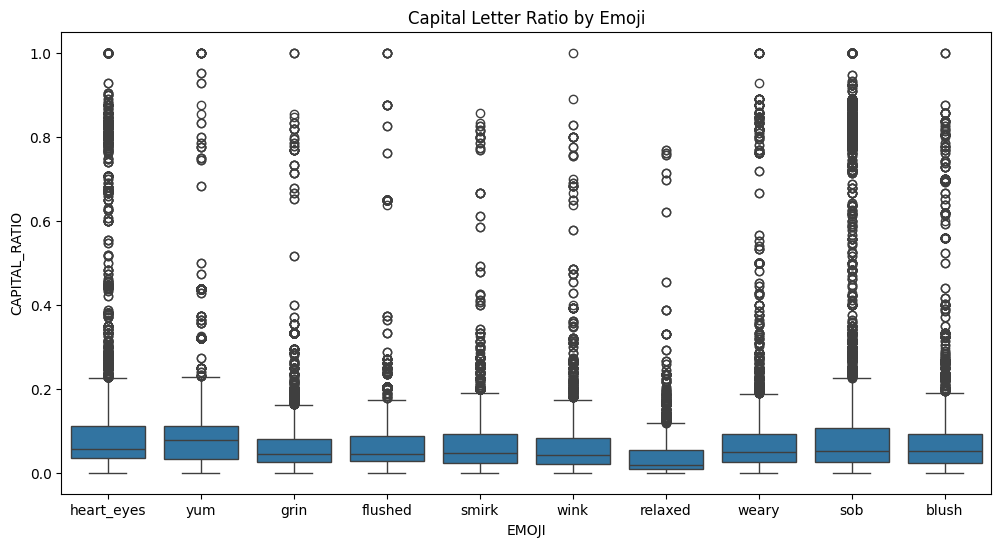

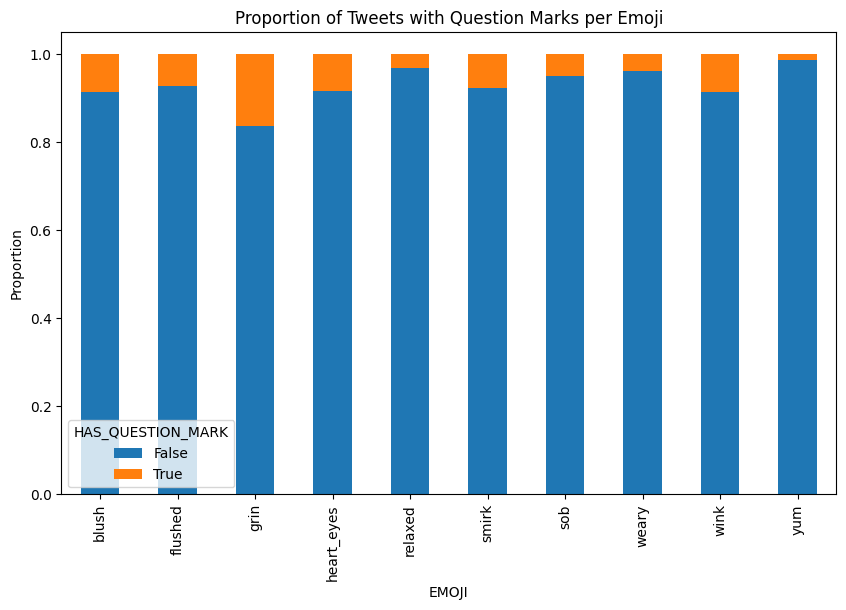

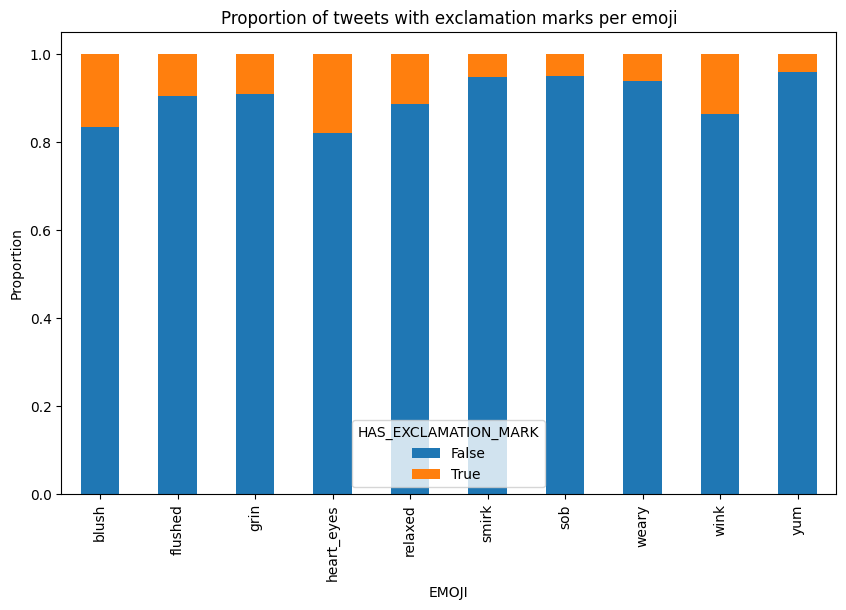

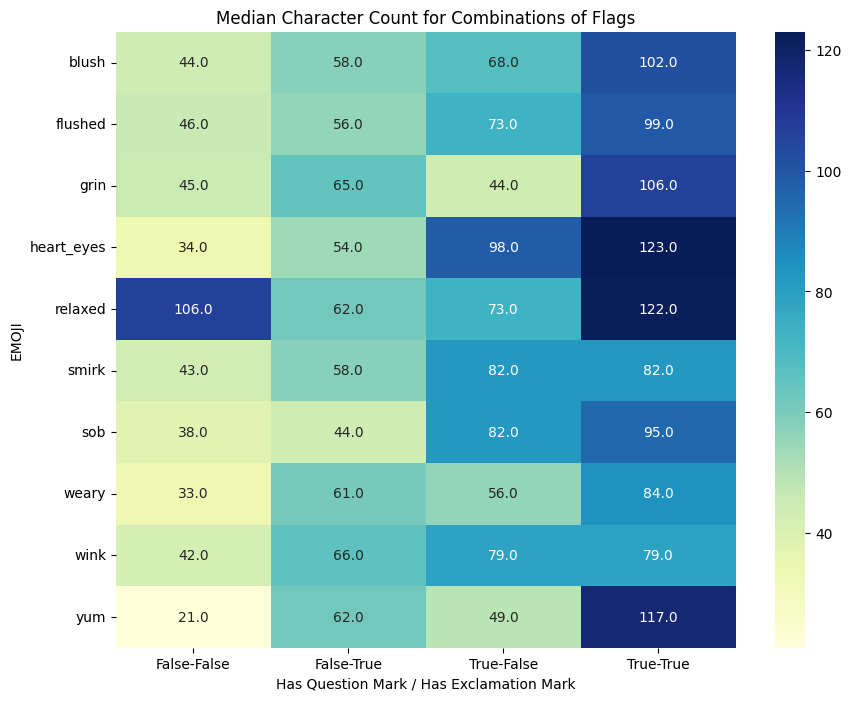

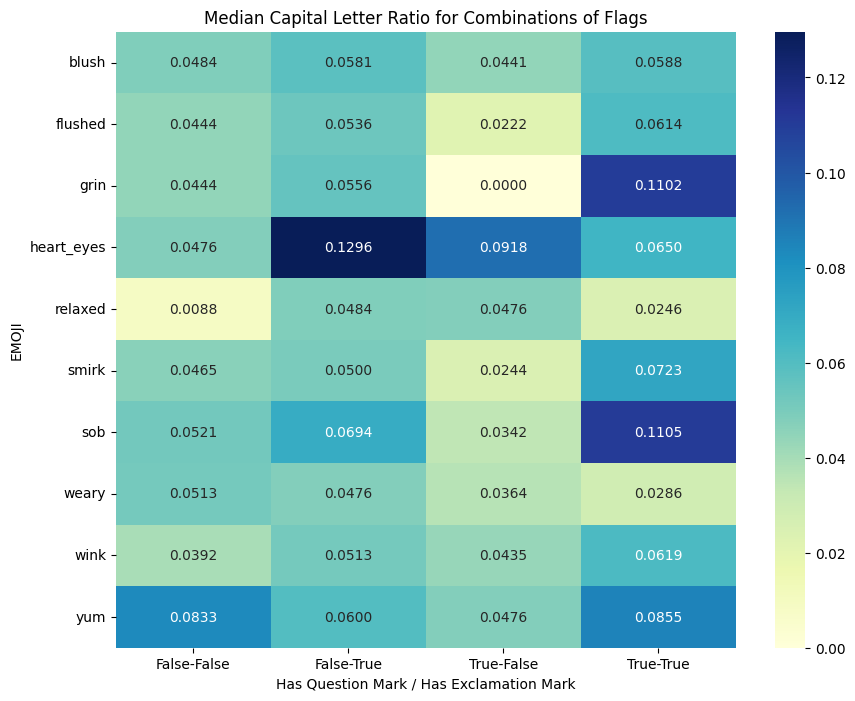

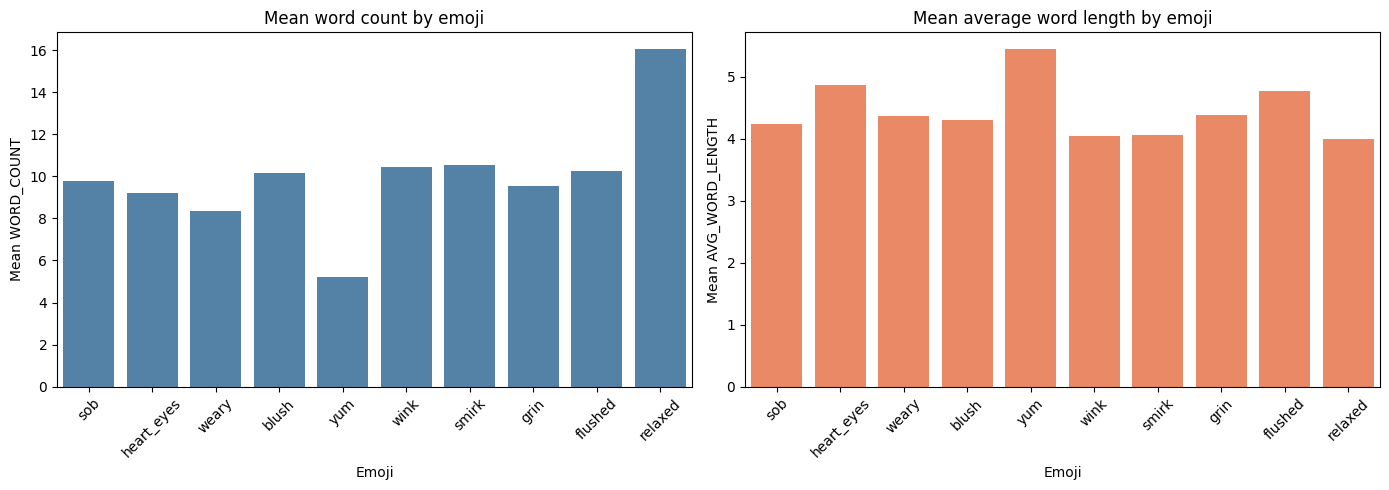

In [88]:
TRAIN_CSV = DATA_DIR / 'filtered_tweets.csv'

df = pd.read_csv(TRAIN_CSV)

# Drop unimportant features
df = df.drop(columns=['LINE_NUM'])

# Only weary and sob
# df = df[df['EMOJI'].isin(['sob', 'weary'])]

# Calculate capital ratio
df['CAPITAL_RATIO'] = df['CAPITAL_LETTER_COUNT'] / df['CHAR_COUNT']

# Target Distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='EMOJI', order=df['EMOJI'].value_counts().index)
plt.title('Distribution of Emojis')
plt.xticks(rotation=45)
plt.show()

# Capital Letters vs Emoji (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='EMOJI', y='CAPITAL_RATIO')
plt.title('Capital Letter Ratio by Emoji')
plt.show()

# Question Marks vs Emoji (Cross-tabulation)
crosstab = pd.crosstab(df['EMOJI'], df['HAS_QUESTION_MARK'], normalize='index')
crosstab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Proportion of Tweets with Question Marks per Emoji')
plt.ylabel('Proportion')
plt.show()

# Exclamation marks vs Emoji (cross-tabulation)
crosstab = pd.crosstab(df['EMOJI'], df['HAS_EXCLAMATION_MARK'], normalize='index')
crosstab.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Proportion of tweets with exclamation marks per emoji')
plt.ylabel('Proportion')
plt.show()


# Character Count Distribution
pivot_table = df.pivot_table(
    values='CHAR_COUNT', 
    index='EMOJI', 
    columns=['HAS_QUESTION_MARK', 'HAS_EXCLAMATION_MARK'], 
    aggfunc='median'
)

# Heat map of character count for combinations of flags
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt=".1f")
plt.title('Median Character Count for Combinations of Flags')
plt.xlabel('Has Question Mark / Has Exclamation Mark')
plt.show()

pivot_table = df.pivot_table(
    values='CAPITAL_RATIO', 
    index='EMOJI', 
    columns=['HAS_QUESTION_MARK', 'HAS_EXCLAMATION_MARK'], 
    aggfunc='median'
)

# Heat map of capital letter ratio for combinations of flags
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt=".4f")
plt.title('Median Capital Letter Ratio for Combinations of Flags')
plt.xlabel('Has Question Mark / Has Exclamation Mark')
plt.show()


# Bar charts: emoji (x) vs mean word count / mean average word length (y)
emoji_order_words = df['EMOJI'].value_counts().index.tolist()
word_by_emoji = (
    df.groupby('EMOJI', observed=False)[['WORD_COUNT', 'AVG_WORD_LENGTH']]
    .mean()
    .reindex(emoji_order_words)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=word_by_emoji,
    x='EMOJI',
    y='WORD_COUNT',
    order=emoji_order_words,
    ax=axes[0],
    color='steelblue',
)
axes[0].set_title('Mean word count by emoji')
axes[0].set_xlabel('Emoji')
axes[0].set_ylabel('Mean WORD_COUNT')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(
    data=word_by_emoji,
    x='EMOJI',
    y='AVG_WORD_LENGTH',
    order=emoji_order_words,
    ax=axes[1],
    color='coral',
)
axes[1].set_title('Mean average word length by emoji')
axes[1].set_xlabel('Emoji')
axes[1].set_ylabel('Mean AVG_WORD_LENGTH')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [89]:
df_shuffled = df.sample(frac=1, random_state=42)

# Limit to 10,000 rows per emoji
df_balanced = df_shuffled.groupby('EMOJI').head(10000)
df_balanced = df_balanced.reset_index(drop=True)

print("New Emoji Distribution:")
print(df_balanced['EMOJI'].value_counts())

New Emoji Distribution:
EMOJI
heart_eyes    10000
weary         10000
sob           10000
blush          8510
yum            8141
wink           7075
smirk          7050
grin           6676
flushed        5477
relaxed        4428
Name: count, dtype: int64


In [90]:
import re
df = df_balanced # Switch to balanced

_token_re = re.compile(r"[a-z0-9']+", re.I)


def tweet_word_tokens(text) -> list[str]:
    return [t for t in _token_re.findall(str(text).lower()) if len(t) >= 3]


_all_tokens: list[str] = []
for tweet in df_balanced['TWEET']:
    _all_tokens.extend(tweet_word_tokens(tweet))

word_counts = pd.Series(_all_tokens, name='token').value_counts()
print(
    f'Unique tokens: {word_counts.size:,} | '
    f'Total tokens: {len(_all_tokens):,}'
)
word_counts.to_csv('word_counts.csv', index=True)

Unique tokens: 13,316 | Total tokens: 566,369


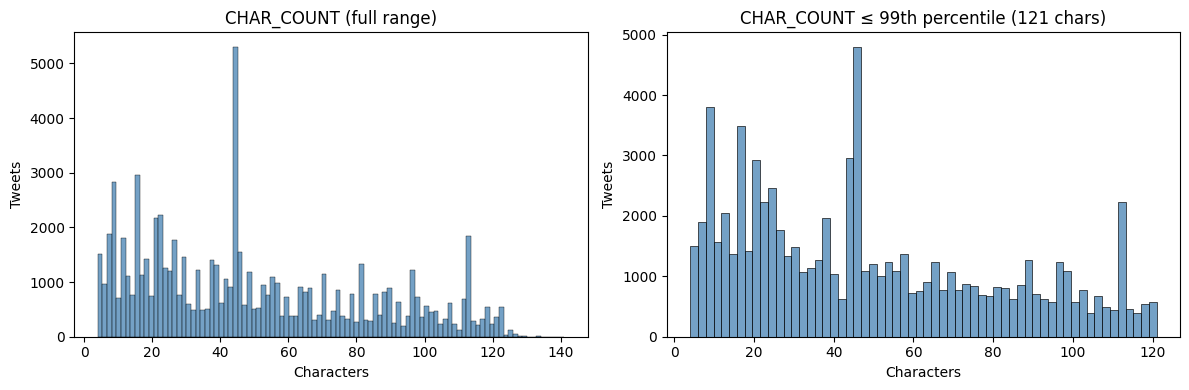

count    77357.000000
mean        49.444782
std         33.149203
min          4.000000
25%         21.000000
50%         44.000000
75%         74.000000
max        141.000000
Name: CHAR_COUNT, dtype: float64


In [91]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['CHAR_COUNT'], bins=100, kde=False, ax=axes[0], color='steelblue')
axes[0].set_title('CHAR_COUNT (full range)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Tweets')

p99 = float(df['CHAR_COUNT'].quantile(0.99))
subset = df.loc[df['CHAR_COUNT'] <= p99, 'CHAR_COUNT']
sns.histplot(subset, bins=60, kde=False, ax=axes[1], color='steelblue')
axes[1].set_title(f'CHAR_COUNT ≤ 99th percentile ({p99:.0f} chars)')
axes[1].set_xlabel('Characters')
axes[1].set_ylabel('Tweets')

plt.tight_layout()
plt.show()

print(df['CHAR_COUNT'].describe())

In [92]:
df['CHAR_COUNT'].value_counts()

CHAR_COUNT
45     3255
9      2836
16     2353
21     2170
44     2050
       ... 
132       2
136       2
137       1
135       1
141       1
Name: count, Length: 134, dtype: int64

In [93]:
# Common words associated with each emoji class
EMOJI_KEYWORDS = {
    'sob':        ['crying', 'cry', 'dead', 'hate', 'miss', 'omg', 'lmao', 'lmfao', 'sad',
                   'hurt', 'broke', 'swear', 'honestly', 'literally', 'omfg', 'ugh',
                   'awful', 'terrible', 'worst', 'kill', 'die', 'dying', 'depressed',
                   'bro', 'lost', 'ruined', 'disappointed', 'devastated', 'broke',
                   'honestly', 'honestly', 'rip', 'fcking', 'fck', 'disgusting'],
    'heart_eyes': ['love', 'beautiful', 'amazing', 'gorgeous', 'cute', 'adorable',
                   'perfect', 'obsessed', 'proud', 'inspired', 'exciting', 'excited',
                   'happy', 'incredible', 'wonderful', 'stunning', 'lovely', 'precious',
                   'sweet', 'aww', 'wow', 'yass', 'goals', 'squad', 'blessed', 'omg',
                   'awww', 'heart', 'bestfriend', 'bestie', 'talent'],
    'yum':        ['starbucks', 'subway', 'mcdonalds', 'pizza', 'food', 'hungry', 'eat',
                   'eating', 'lunch', 'dinner', 'breakfast', 'coffee', 'burger', 'fries',
                   'chicken', 'taco', 'sushi', 'donut', 'cake', 'cookie', 'snack',
                   'delicious', 'yummy', 'nom', 'tasty', 'drink', 'juice', 'latte',
                   'pumpkin', 'spice', 'dominos', 'chipotle', 'wings', 'nuggets',
                   'salad', 'sandwich', 'ice', 'cream', 'chocolate'],
    'weary':      ['want', 'need', 'miss', 'tired', 'exhausted', 'ugh', 'please',
                   'starbucks', 'subway', 'dominos', 'mcdonalds', 'hungry', 'craving',
                   'wish', 'someone', 'help', 'ughhh', 'ugh', 'though', 'honestly',
                   'whyyy', 'why', 'uglyy', 'lowkey', 'smh', 'rn', 'pls'],
    'blush':      ['bet', 'thank', 'thanks', 'congrats', 'omg', 'lol', 'walmart',
                   'starbucks', 'haha', 'yay', 'hehe', 'wow', 'blushing', 'embarrassing',
                   'awkward', 'cute', 'sweet', 'aww', 'blessed', 'luck', 'proud'],
    'smirk':      ['bet', 'know', 'name', 'like', 'think', 'sure', 'dare', 'play',
                   'laugh', 'funny', 'haha', 'lol', 'shade', 'slay', 'winning',
                   'confident', 'sass', 'petty', 'lowkey', 'nah', 'yall', 'tho', 'doe'],
    'grin':       ['bet', 'lol', 'haha', 'funny', 'love', 'great', 'good', 'starbucks',
                   'happy', 'awesome', 'wow', 'yes', 'yess', 'nice', 'lit', 'fire',
                   'amazing', 'hahaha', 'hilarious', 'omg', 'bestday', 'classic',
                   'proud', 'hyped', 'excited', 'woah'],
    'wink':       ['bet', 'know', 'sure', 'guess', 'think', 'probably', 'maybe',
                   'doubt', 'believe', 'though', 'right', 'waiting', 'hint', 'secret',
                   'wonder', 'clever', 'sneaky', 'playful', 'obvious', 'clearly'],
    'relaxed':    ['thank', 'happy', 'love', 'blessed', 'good', 'great', 'beautiful',
                   'life', 'enjoy', 'peace', 'calm', 'chill', 'grateful', 'glad',
                   'thankful', 'excited', 'proud', 'vibes', 'positive', 'wonderful',
                   'content', 'satisfied', 'lovely', 'perfect', 'morning', 'sunshine'],
    'flushed':    ['walmart', 'mcdonalds', 'omg', 'wait', 'what', 'really', 'excuse',
                   'damn', 'wow', 'shocked', 'speechless', 'confused', 'seriously',
                   'actually', 'literally', 'rude', 'inappropriate', 'starbucks',
                   'disgusting', 'awkward', 'embarrassed', 'caught', 'surprised'],
}

# Common phrase patterns
EMOJI_PHRASE_PATTERNS = [
    (r'\bstarbucks\b',          'has_starbucks'),
    (r'\bsubway\b',             'has_subway'),
    (r'\bmcdonalds?\b',         'has_mcdonalds'),
    (r'\bdominos?\b',           'has_dominos'),
    (r'\bwalmart\b',            'has_walmart'),
    (r'\bchick.fil.a\b',        'has_chickfila'),
    (r'\bi (love|luv)\b',       'has_i_love'),
    (r'\bi (miss|missed)\b',    'has_i_miss'),
    (r'\bi (hate|hated)\b',     'has_i_hate'),
    (r'\bi want\b',             'has_i_want'),
    (r'\bi need\b',             'has_i_need'),
    (r'\bthank\b',              'has_thank'),
    (r'\b(lmao|lmfao|lmaoo)\b', 'has_lmao'),
    (r'\b(haha|hahaha|lol)\b',  'has_laugh'),
    (r'\b(crying|cried|cry)\b', 'has_cry'),
    (r'\b(dead|dying)\b',       'has_dead'),
    (r'\b(wow|omg|omfg)\b',     'has_wow'),
    (r'\bbet\b',                'has_bet'),
    (r'\b(beautiful|gorgeous|stunning)\b', 'has_beautiful'),
    (r'\b(hungry|craving|starving)\b',     'has_hungry'),
    (r'\b(please|pls|plz)\b',              'has_please'),
    (r'\b(wait|waiting)\b',                'has_wait'),
    (r'\b(proud|pride)\b',                 'has_proud'),
    (r'\b(blessed|blessing)\b',            'has_blessed'),
]

import re

# Add search features for keywords and phrases
_tl = df['TWEET'].astype(str).str.strip().str.lower()
_emoji_order = list(EMOJI_KEYWORDS)

_kw_rows = [
    [
        int(any(re.search(r'\b' + re.escape(kw) + r'\b', s) for kw in EMOJI_KEYWORDS[em]))
        for em in _emoji_order
    ]
    for s in _tl
]
_kw_df = pd.DataFrame(
    _kw_rows,
    columns=[f'kw_{em}' for em in _emoji_order],
    index=df.index,
)

_phrase_cols = [name for _, name in EMOJI_PHRASE_PATTERNS]
_phrase_rows = [
    [int(bool(re.search(pat, s))) for pat, _ in EMOJI_PHRASE_PATTERNS]
    for s in _tl
]
_phrase_df = pd.DataFrame(_phrase_rows, columns=_phrase_cols, index=df.index)

_feat_cols = list(_kw_df.columns) + list(_phrase_df.columns)
df = df.drop(columns=[c for c in _feat_cols if c in df.columns], errors='ignore')
df = pd.concat([df, _kw_df, _phrase_df], axis=1)



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Don't use label, raw text, or line id as tabular features
_LEAK_COLS = frozenset({"EMOJI", "TWEET", "LINE_NUM"})

X = (
    df.drop(columns=list(_LEAK_COLS), errors="ignore")
    .select_dtypes(include=["number", "bool"])
)
X = X[[c for c in X.columns if c not in _LEAK_COLS]]
y = df["EMOJI"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

feature_imp = pd.DataFrame(
    {"feature": X.columns, "importance": rf_model.feature_importances_}
)
feature_imp = feature_imp[feature_imp["importance"] > 0.01].sort_values(
    "importance", ascending=False
)

# Train-only RF importances -> list of metadata column names (EMOJI never in X)
selected_meta_cols = [f for f in feature_imp["feature"].tolist() if f not in _LEAK_COLS]

feature_imp


,feature,importance
2,AVG_WORD_LENGTH,0.155918
0,CHAR_COUNT,0.155393
9,CAPITAL_RATIO,0.137637
1,WORD_COUNT,0.113805
3,CAPITAL_LETTER_COUNT,0.080897
4,MENTION_COUNT,0.051445
8,IS_RETWEET,0.021107
12,kw_yum,0.018954
18,kw_relaxed,0.018530
10,kw_sob,0.018018


model

In [95]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier

_model_keep = ["EMOJI", "TWEET"] + [c for c in selected_meta_cols if c in df.columns]
df_model = df[_model_keep].copy()

le = LabelEncoder()
y = le.fit_transform(df_model["EMOJI"])

# BERT sentence embeddings (384-dim for all-MiniLM-L6-v2)
print("Generating BERT embeddings...")
_st_model = SentenceTransformer("all-MiniLM-L6-v2")
X_bert = np.vstack(
    _st_model.encode(df_model["TWEET"].astype(str).tolist(), show_progress_bar=True)
)

metadata_cols = [c for c in selected_meta_cols if c in df_model.columns]
scaler = StandardScaler()
X_meta = scaler.fit_transform(df_model[metadata_cols])

idx_train, idx_test, y_train, y_test = train_test_split(
    np.arange(len(y)), y, test_size=0.2, random_state=42, stratify=y
)

# RF Classifier
def evaluate_model(X_name, X_features):
    print(f"\nTraining Model: {X_name}...")
    X_tr, X_te = X_features[idx_train], X_features[idx_test]
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_tr, y_train)
    preds = clf.predict(X_te)
    score = f1_score(y_test, preds, average='macro')
    print(f"{X_name} Macro F1-Score: {score:.4f}")
    return score, preds

# Metadata-only vs BERT-embedding RF (same train/test split)
score_meta, preds_meta = evaluate_model("Metadata (RF)", X_meta)
score_bert, preds_bert = evaluate_model("BERT (RF)", X_bert)

print("\n--- FINAL RESULTS (Metadata vs BERT) ---")
print(f"Metadata F1: {score_meta:.4f}")
print(f"BERT F1:     {score_bert:.4f}")

# Save failed cases to CSV for edge case analysis
bert_mis = pd.DataFrame(
    {
        'TWEET': df_model.iloc[idx_test]['TWEET'].astype(str).values,
        'true_emoji': le.inverse_transform(y_test),
        'pred_emoji': le.inverse_transform(preds_bert),
    }
)
bert_wrong = bert_mis[bert_mis['true_emoji'] != bert_mis['pred_emoji']]
_bert_mis_path = 'data/bert_rf_misclassified.csv'
bert_wrong.to_csv(_bert_mis_path, index=False)
print(
    f"\nBERT+RF misclassified: {len(bert_wrong)} / {len(idx_test)} test tweets -> {_bert_mis_path}"
)

meta_mis = pd.DataFrame(
    {
        'TWEET': df_model.iloc[idx_test]['TWEET'].astype(str).values,
        'true_emoji': le.inverse_transform(y_test),
        'pred_emoji': le.inverse_transform(preds_meta),
    }
)
meta_wrong = meta_mis[meta_mis['true_emoji'] != meta_mis['pred_emoji']]
_meta_mis_path = 'data/meta_rf_misclassified.csv'
meta_wrong.to_csv(_meta_mis_path, index=False)
print(
    f"Metadata+RF misclassified: {len(meta_wrong)} / {len(idx_test)} test tweets -> {_meta_mis_path}"
)


Generating BERT embeddings...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12038.49it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 2418/2418 [01:19<00:00, 30.25it/s]



Training Model: Metadata (RF)...
Metadata (RF) Macro F1-Score: 0.7157

Training Model: BERT (RF)...
BERT (RF) Macro F1-Score: 0.8512

--- FINAL RESULTS (Metadata vs BERT) ---
Metadata F1: 0.7157
BERT F1:     0.8512

BERT+RF misclassified: 2543 / 15472 test tweets -> data/bert_rf_misclassified.csv
Metadata+RF misclassified: 4655 / 15472 test tweets -> data/meta_rf_misclassified.csv


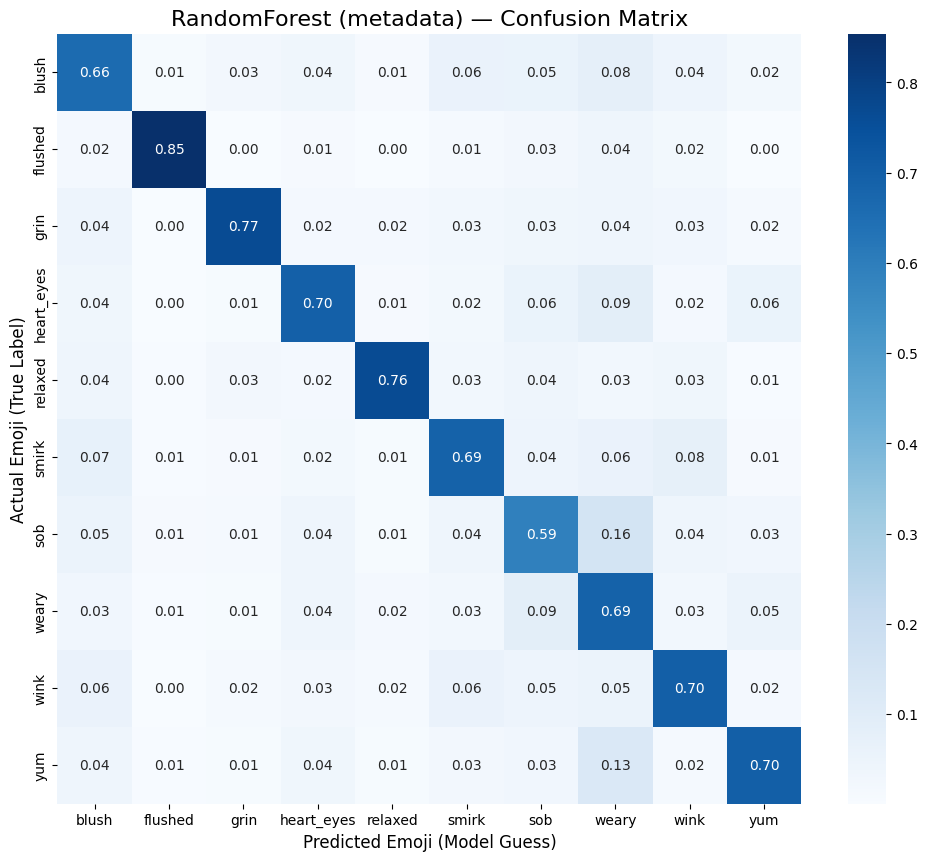

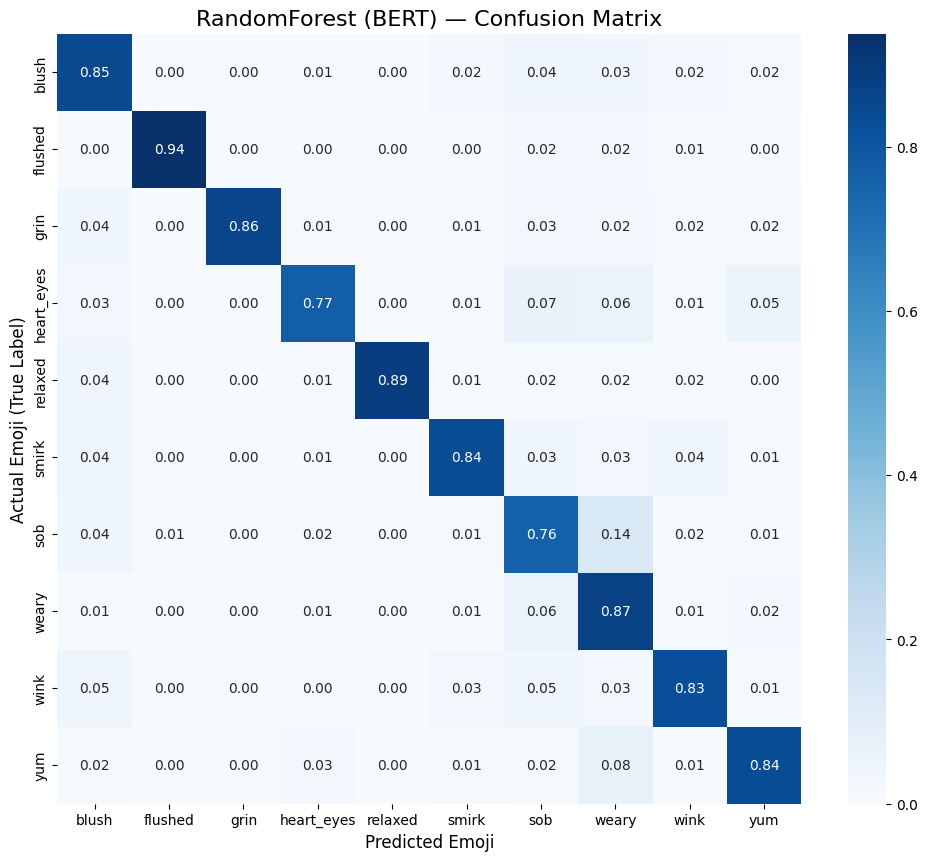

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Metadata-only RandomForest (same split as main modeling cell)
_clf_cm = RandomForestClassifier(n_estimators=100, random_state=42).fit(
    X_meta[idx_train], y_train
)
_preds_cm = _clf_cm.predict(X_meta[idx_test])

# Graph relative confusion matrix
cm = confusion_matrix(y_test, _preds_cm, normalize='true')

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)

plt.title('RandomForest (metadata) — Confusion Matrix', fontsize=16)
plt.ylabel('Actual Emoji (True Label)', fontsize=12)
plt.xlabel('Predicted Emoji', fontsize=12)
plt.show()

# BERT embeddings + RandomForest (same split as main modeling cell)
_clf_bert_cm = RandomForestClassifier(n_estimators=100, random_state=42).fit(
    X_bert[idx_train], y_train
)
_preds_bert_cm = _clf_bert_cm.predict(X_bert[idx_test])

# Graph relative confusion matrix
cm_bert = confusion_matrix(y_test, _preds_bert_cm, normalize='true')

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_bert,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
)
plt.title('RandomForest (BERT) — Confusion Matrix', fontsize=16)
plt.ylabel('Actual Emoji (True Label)', fontsize=12)
plt.xlabel('Predicted Emoji', fontsize=12)
plt.show()

In [97]:
from sklearn.ensemble import RandomForestClassifier

# Metadata-only RandomForest (BERT path commented in main cell)
clf_meta = RandomForestClassifier(n_estimators=100, random_state=42).fit(
    X_meta[idx_train], y_train
)
preds_meta = clf_meta.predict(X_meta[idx_test])

# --- (commented) BERT RF + meta-vs-BERT disagreement analysis ---
# clf_bert = RandomForestClassifier(n_estimators=100, random_state=42).fit(
#     X_bert[idx_train], y_train
# )
# preds_bert = clf_bert.predict(X_bert[idx_test])
# disagreement_df = pd.DataFrame({
#     'Tweet': df['TWEET'].iloc[idx_test].values,
#     'Actual_Emoji': le.inverse_transform(y_test),
#     'Meta_Guess': le.inverse_transform(preds_meta),
#     'BERT_Guess': le.inverse_transform(preds_bert),
# })
# meta_wins = disagreement_df[
#     (disagreement_df['Actual_Emoji'] == disagreement_df['Meta_Guess'])
#     & (disagreement_df['Actual_Emoji'] != disagreement_df['BERT_Guess'])
# ]
# print(f"Found {len(meta_wins)} tweets where Metadata beat BERT.")
# for idx, row in meta_wins.head(20).iterrows():
#     print(f"\nActual: {row['Actual_Emoji']} | BERT Guessed: {row['BERT_Guess']}")
#     print(f"Tweet: {row['Tweet']}")